# The Case for Private Markets, Told Entirely From Public Data

*StartEngine research notebook · June 2026 · **DRAFT — for internal review***

Three facts about American capital markets, each drawn from a government data source —
the Federal Reserve, the SEC, the IRS, and the Census Bureau — and each pulled **live by
the code in this notebook**, so every figure is reproducible by anyone who runs it:

1. **The public stock market has been shrinking for nearly three decades.**
2. **Capital formation didn't shrink with it — it moved into private markets.**
3. **For most of that time, the overwhelming majority of Americans were not allowed to participate.**

None of this is a forecast, and none of it is investment advice. It is simply what the
public record says — and together, it is the clearest picture of why private markets are
one of the largest under-served opportunities in American investing.

In [1]:
import os, datetime as dt, asyncio, sqlite3, json, logging
from types import SimpleNamespace

# Cap noisy INFO loggers: httpx logs full request URLs (which carry API keys
# as query params) and matplotlib chatters about categorical axes.
for _name in ("httpx", "httpcore", "matplotlib"):
    logging.getLogger(_name).setLevel(logging.WARNING)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import Markdown, display

def callout(text):
    display(Markdown(f"> **{text}**"))
from IPython.display import Markdown, display

def callout(text):
    display(Markdown(f"> **{text}**"))

# --- the four open-source data servers (installed from PyPI) ---------------
os.environ.setdefault("EDGAR_MCP_USER_AGENT", "StartEngine research devender@startengine.com")
assert os.environ.get("FRED_API_KEY"), "set FRED_API_KEY (free: fred.stlouisfed.org/docs/api/api_key_request.html)"

from fred_mcp import server as fred_server
from fred_mcp.fred_client import FredClient
from edgar_mcp import server as edgar_server
from edgar_mcp.edgar_client import EdgarClient
from mcpwright_core import cache_path

def _ctx(**resources):
    """Minimal MCP Context stand-in so we can call the servers' tools directly."""
    return SimpleNamespace(request_context=SimpleNamespace(lifespan_context=SimpleNamespace(**resources)))

fred_client = FredClient()
edgar_client = EdgarClient()
FRED = _ctx(fred=fred_client)
EDGAR = _ctx(edgar=edgar_client)
SOI_DB = cache_path("mcpwright-soi", "soi.sqlite3", "SOI_MCP_STORE")
ACS_DB = cache_path("mcpwright-census", "acs.sqlite3", "CENSUS_MCP_STORE")

# StartEngine brand palette
ACCENT, DEEP, DIM, GOOD = "#01D1B8", "#185C65", "#9AA5A6", "#185C65"
sns.set_theme(style="whitegrid", context="notebook", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
TODAY = dt.date.today()
display(Markdown(f"*All live figures in this document were pulled on {TODAY.isoformat()}.*"))

*All live figures in this document were pulled on 2026-06-10.*

## 1 · The public stock market has been shrinking for 30 years

In 1996 the United States had more listed companies, per person, than at any point before
or since. Then the IPO stopped being the default destination for a growing company.
Companies now stay private longer — often through their fastest-growing years — and many
never list at all. The World Bank tracks listed companies per capita; the Federal Reserve's
FRED database carries the series.

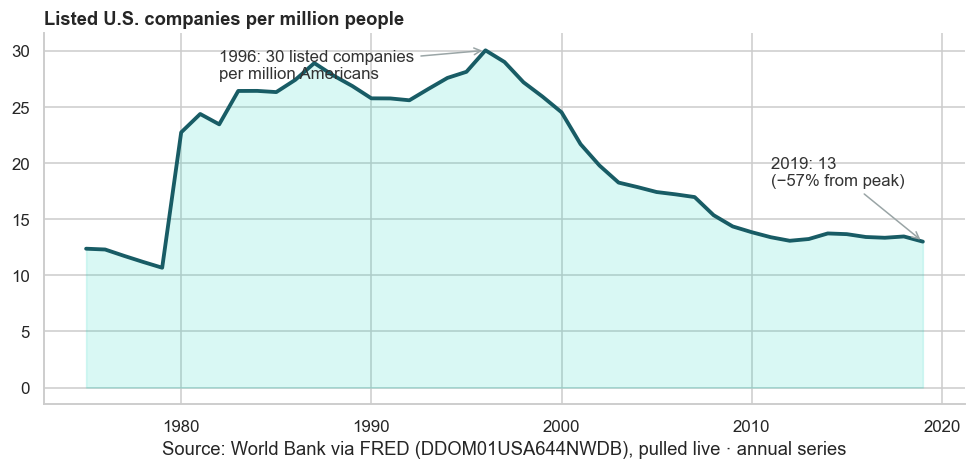

> **Peak 1996: 30 listed companies per million Americans → 2019: 13 — a 57% decline.**

In [2]:
hits = await fred_server.search_series("listed companies United States", FRED, limit=1)
series_id = hits[0].series_id
listed = await fred_server.get_observations(series_id, FRED, max_points=60)
pts = [(int(o.date[:4]), o.value) for o in listed.observations if o.value is not None]
years, vals = zip(*pts)
peak_year, peak = max(pts, key=lambda p: p[1])
last_year, last = pts[-1]
decline = (peak - last) / peak * 100

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(years, vals, color=DEEP, lw=2.5)
ax.fill_between(years, vals, color=ACCENT, alpha=0.15)
ax.annotate(f"{peak_year}: {peak:.0f} listed companies\nper million Americans",
            xy=(peak_year, peak), xytext=(peak_year - 14, peak - 2.5),
            arrowprops=dict(arrowstyle="->", color=DIM), color="#333")
ax.annotate(f"{last_year}: {last:.0f}\n(−{decline:.0f}% from peak)",
            xy=(last_year, last), xytext=(last_year - 8, last + 5),
            arrowprops=dict(arrowstyle="->", color=DIM), color="#333")
ax.set_title("Listed U.S. companies per million people", loc="left", fontweight="bold")
ax.set_xlabel(f"Source: World Bank via FRED ({series_id}), pulled live · annual series")
plt.tight_layout(); plt.show()

callout(f"Peak {peak_year}: {peak:.0f} listed companies per million Americans → {last_year}: "
        f"{last:.0f} — a {decline:.0f}% decline.")

The U.S. population grew by a quarter over this period; the number of public companies
fell anyway. The consequence for investors is structural: **by the time a company reaches
the public market — if it ever does — much of its growth has already happened**, captured
by whoever was allowed to own it while it was private.

## 2 · Capital formation didn't shrink. It moved.

If companies aren't going public, where is the capital being raised? The SEC's own filing
system answers in real time. Every private placement under Regulation D files a **Form D**;
every regulated crowdfunding raise files a **Form C**. The cell below counts the last
twelve months of Form D filings, live from SEC EDGAR's full-text search index.

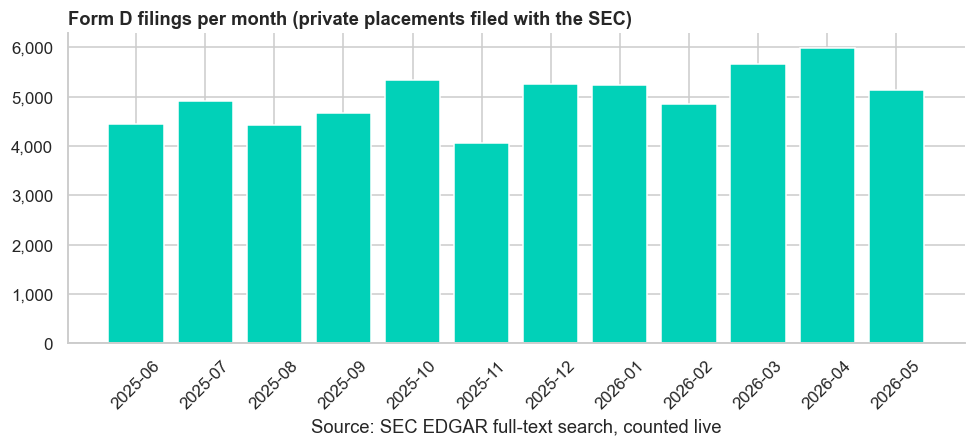

> **59,898 Form D filings in the last 12 full months — about 164 new private placements filed every single day.**

In [3]:
async def month_total(form, y, m):
    start = dt.date(y, m, 1)
    end = (dt.date(y + (m == 12), m % 12 + 1, 1) - dt.timedelta(days=1))
    data = await edgar_client.full_text_search(forms=[form], date_from=start.isoformat(),
                                               date_to=end.isoformat())
    return data.get("hits", {}).get("total", {}).get("value", 0)

months = []
y, m = TODAY.year, TODAY.month
for _ in range(12):
    m -= 1
    if m == 0:
        y, m = y - 1, 12
    months.append((y, m))
months.reverse()

formd = [await month_total("D", y, m) for y, m in months]
labels = [f"{y}-{m:02d}" for y, m in months]
total_12mo = sum(formd)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(labels, formd, color=ACCENT)
ax.set_title("Form D filings per month (private placements filed with the SEC)",
             loc="left", fontweight="bold")
ax.set_xlabel("Source: SEC EDGAR full-text search, counted live")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

callout(f"{total_12mo:,} Form D filings in the last 12 full months — about "
        f"{total_12mo//365} new private placements filed every single day.")

How does that compare with companies taking the public on-ramp? Counting from the same
SEC index over the same twelve months: **Form D** (raising privately) versus **S-1**
(registering to go public) versus **424B4** (the final prospectus of a *priced* IPO —
deals that actually happened). And in dollars, the SEC's latest
[capital formation data](https://www.sec.gov/data-research/statistics-data-visualizations/regulation-d-offerings)
(July 2023–June 2024) puts exempt offerings by operating companies at about
**\$949 billion** against about **\$28 billion** of IPOs — including pooled funds,
Regulation D alone has run at **\$2.5+ trillion a year**.

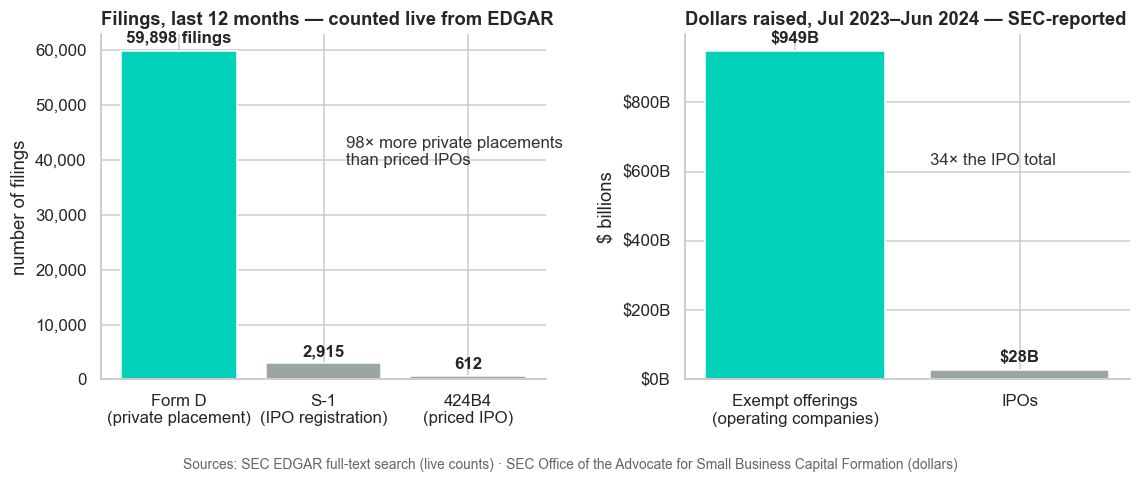

> **Last 12 months: 59,898 private placements vs 2,915 IPO registrations vs 612 priced IPOs — 98× more companies raised privately than completed an IPO.**

In [4]:
s1_total = sum([await month_total("S-1", y, m) for y, m in months])
b4_total = sum([await month_total("424B4", y, m) for y, m in months])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.4))

counts = [total_12mo, s1_total, b4_total]
count_labels = ["Form D\n(private placement)", "S-1\n(IPO registration)", "424B4\n(priced IPO)"]
bars = ax1.bar(count_labels, counts, color=[ACCENT, DIM, DIM])
ax1.bar_label(bars, labels=[f"{counts[0]:,} filings", f"{counts[1]:,}", f"{counts[2]:,}"],
              padding=3, fontweight="bold")
ax1.set_title("Filings, last 12 months — counted live from EDGAR", loc="left", fontweight="bold")
ax1.set_ylabel("number of filings")
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax1.annotate(f"{total_12mo / b4_total:.0f}× more private placements\nthan priced IPOs",
             xy=(0.55, 0.62), xycoords="axes fraction", color="#333")

dollars = [949, 28]
dollar_labels = ["Exempt offerings\n(operating companies)", "IPOs"]
bars2 = ax2.bar(dollar_labels, dollars, color=[ACCENT, DIM])
ax2.bar_label(bars2, fmt="$%gB", padding=3, fontweight="bold")
ax2.set_title("Dollars raised, Jul 2023–Jun 2024 — SEC-reported", loc="left", fontweight="bold")
ax2.set_ylabel("$ billions")
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}B"))
ax2.annotate("34× the IPO total", xy=(0.55, 0.62), xycoords="axes fraction", color="#333")

fig.supxlabel("Sources: SEC EDGAR full-text search (live counts) · SEC Office of the Advocate for "
              "Small Business Capital Formation (dollars)", fontsize=9, color="#666")
plt.tight_layout(); plt.show()

callout(f"Last 12 months: {total_12mo:,} private placements vs {s1_total:,} IPO registrations "
        f"vs {b4_total:,} priced IPOs — {total_12mo/b4_total:.0f}× more companies raised "
        f"privately than completed an IPO.")

The American capital market did not get smaller. It went private. A few of the most
recent private placements on file as this notebook runs:

In [5]:
recent = await edgar_server.get_recent_offerings(EDGAR, form="D", limit=8)
rows = []
for o in recent[:8]:
    rows.append({"Filed": o.filed, "Issuer": o.issuer, "Form": o.form})
pd.DataFrame(rows)

,Filed,Issuer,Form
0,2026-06-10,Shoppes of Midtown Mobile LLC (CIK 0002140137),D
1,2026-06-10,Interwoven Ventures S4 LLC (CIK 0002140123),D
2,2026-06-10,Anthracite Aviation LLC (CIK 0002140114),D
3,2026-06-10,"BEL AIR APARTMENT FUND ONE, LLC (CIK 0002140057)",D
4,2026-06-10,trainedB.ai Inc. (CIK 0002140008),D
5,2026-06-10,GrowthIQ AI Inc. (CIK 0002140005),D
6,2026-06-10,26N Partners LLC (CIK 0002140003),D
7,2026-06-10,Aeterna WYM LLC (CIK 0002139983),D


## 3 · Who was allowed in

For decades, participating in that private market generally required being an
**accredited investor** — for most individuals, an income above \$200,000 or a
million-dollar net worth excluding the home. How many Americans actually clear that
income bar? The IRS publishes the answer, aggregated from every filed tax return.

<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
/var/folders/v4/2_ch3kcd0z5b0td0hzd0trgc0000gn/T/ipykernel_28890/2207486227.py:22: SyntaxWarning: invalid escape sequence '\$'
  callout(f"{share:.1f}% of U.S. tax returns show income above \$200k — "


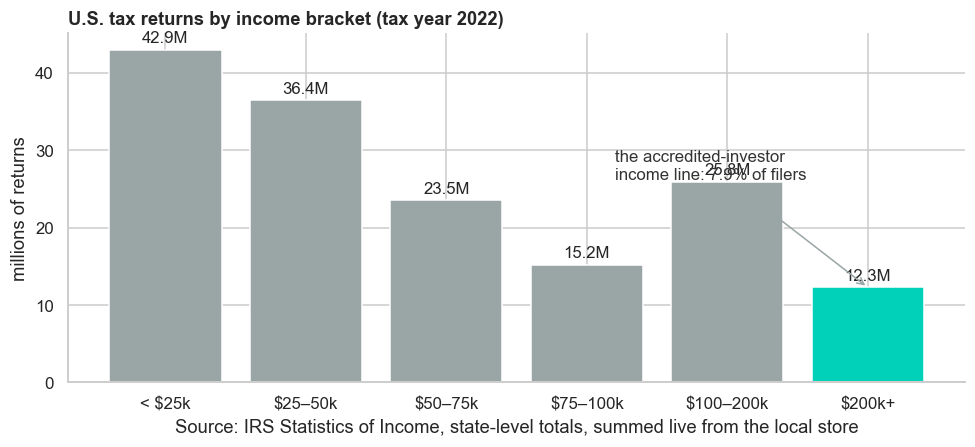

> **7.9% of U.S. tax returns show income above \$200k — 92.1% of American tax filers sit below the accredited-investor income line.**

In [6]:
con = sqlite3.connect(SOI_DB)
brackets = pd.read_sql_query(
    "SELECT agi_stub, SUM(n1) AS returns FROM soi WHERE zipcode='00000' GROUP BY agi_stub", con)
con.close()
bracket_labels = ["< $25k", "$25–50k", "$50–75k", "$75–100k", "$100–200k", "$200k+"]
total_returns = brackets["returns"].sum()
over = int(brackets.loc[brackets.agi_stub == 6, "returns"].iloc[0])
share = over / total_returns * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [DIM] * 5 + [ACCENT]
bars = ax.bar(bracket_labels, brackets["returns"] / 1e6, color=colors)
ax.bar_label(bars, fmt="%.1fM", padding=3)
ax.set_title("U.S. tax returns by income bracket (tax year 2022)", loc="left", fontweight="bold")
ax.set_ylabel("millions of returns")
ax.set_xlabel("Source: IRS Statistics of Income, state-level totals, summed live from the local store")
ax.annotate(f"the accredited-investor\nincome line: {share:.1f}% of filers",
            xy=(5, over / 1e6), xytext=(3.2, over / 1e6 + 14),
            arrowprops=dict(arrowstyle="->", color=DIM), color="#333")
plt.tight_layout(); plt.show()

callout(f"{share:.1f}% of U.S. tax returns show income above \$200k — "
        f"{100-share:.1f}% of American tax filers sit below the accredited-investor income line.")

<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
/var/folders/v4/2_ch3kcd0z5b0td0hzd0trgc0000gn/T/ipykernel_28890/2191072541.py:23: SyntaxWarning: invalid escape sequence '\$'
  f"household clears \$200k; nationally, {hh_share:.1f}% of households do.")


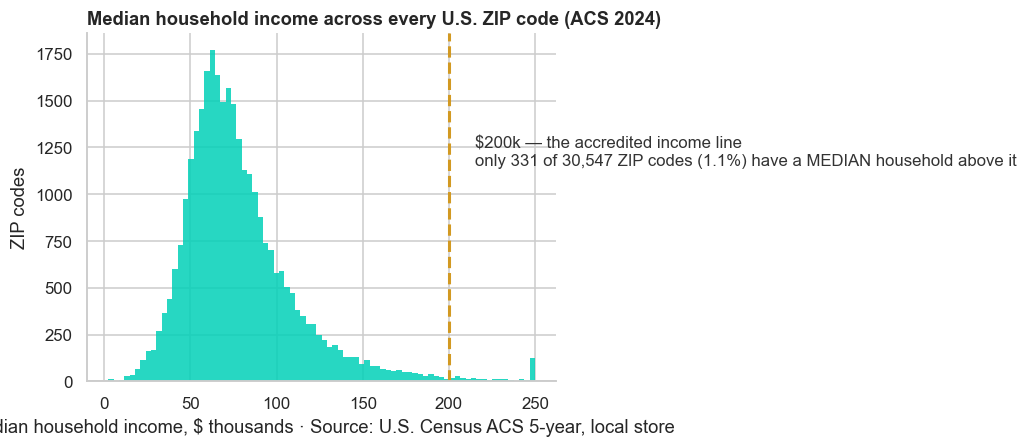

> **In 331 of 30,547 U.S. ZIP codes (1.1%), the median household clears \$200k; nationally, 13.3% of households do.**

In [7]:
con = sqlite3.connect(ACS_DB)
zips = pd.read_sql_query(
    "SELECT median_household_income AS mhi, total_households AS hh, households_200k_plus AS hh200 "
    "FROM zcta WHERE median_household_income IS NOT NULL", con)
con.close()
n_zips = len(zips)
rich_zips = int((zips.mhi >= 200_000).sum())
hh_share = zips.hh200.sum() / zips.hh.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.histplot(zips.mhi / 1000, bins=80, color=ACCENT, alpha=0.85, ax=ax, edgecolor="none")
ax.axvline(200, color="#d29922", lw=2, ls="--")
ax.annotate(f"$200k — the accredited income line\nonly {rich_zips} of {n_zips:,} ZIP codes "
            f"({rich_zips/n_zips:.1%}) have a MEDIAN household above it",
            xy=(200, ax.get_ylim()[1] * 0.55), xytext=(215, ax.get_ylim()[1] * 0.62), color="#333")
ax.set_title("Median household income across every U.S. ZIP code (ACS 2024)",
             loc="left", fontweight="bold")
ax.set_xlabel("median household income, $ thousands · Source: U.S. Census ACS 5-year, local store")
ax.set_ylabel("ZIP codes")
plt.tight_layout(); plt.show()

callout(f"In {rich_zips} of {n_zips:,} U.S. ZIP codes ({rich_zips/n_zips:.1%}), the median "
        f"household clears \$200k; nationally, {hh_share:.1f}% of households do.")

Read those two charts together: the part of the market where capital formation actually
happens was, by income test, effectively closed to roughly **9 in 10 American tax filers**
— and in **99 of 100 ZIP codes**, the *typical* household didn't qualify.

## 4 · The wall has a door now

Regulation Crowdfunding went live in May 2016: for the first time since 1933, any
American — accredited or not — can invest in private companies through regulated
platforms, with investor-protection limits built in. Every such offering files a
**Form C** with the SEC. The filings are countable, live:

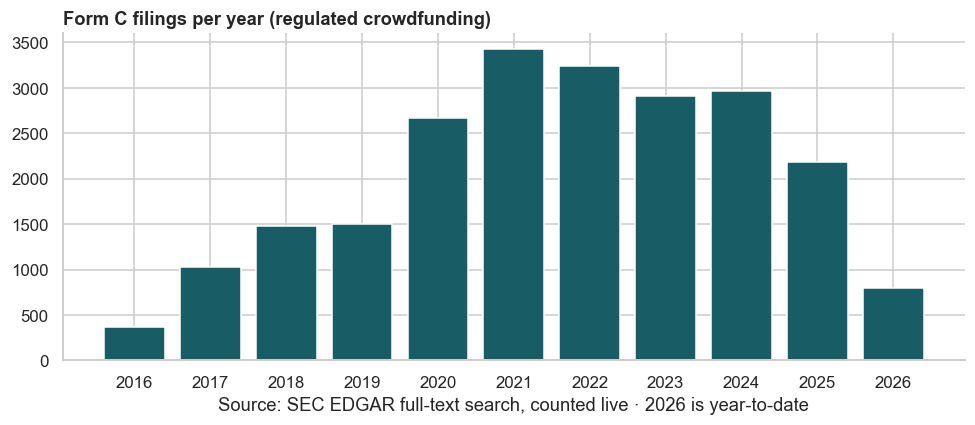

> **22,560 Form C filings since Regulation Crowdfunding went live in May 2016.**

In [8]:
# Count per year and sum: EDGAR's search index caps any single count at 10,000,
# so one big 2016-to-today query would silently understate the total.
yearly = []
for yr in range(2016, TODAY.year + 1):
    start = "2016-05-16" if yr == 2016 else f"{yr}-01-01"
    d = await edgar_client.full_text_search(forms=["C"], date_from=start,
                                            date_to=f"{yr}-12-31")
    yearly.append((yr, d.get("hits", {}).get("total", {}).get("value", 0)))
formc_total = sum(c for _y, c in yearly)

ys, cs = zip(*yearly)
fig, ax = plt.subplots(figsize=(9, 4.0))
ax.bar([str(y) for y in ys], cs, color=GOOD)
ax.set_title("Form C filings per year (regulated crowdfunding)", loc="left", fontweight="bold")
ax.set_xlabel(f"Source: SEC EDGAR full-text search, counted live · {TODAY.year} is year-to-date")
plt.tight_layout(); plt.show()

callout(f"{formc_total:,} Form C filings since Regulation Crowdfunding went live in May 2016.")

The numbers are still small next to Regulation D — which is exactly the point. The asset
class that raises **thirty times** what IPOs do was opened to everyday investors less
than a decade ago.

And the opening runs in both directions. Even among the 7.9% of filers who *do* clear the
accreditation bar, access to private deal flow has historically been gated by networks and
minimum checks rather than rules — most accredited investors never saw the offerings behind
those 59,898 Form Ds. Regulated platforms now bring Regulation D offerings directly to
accredited investors (StartEngine Private among them), alongside the Regulation
Crowdfunding and Regulation A offerings open to everyone. The gap between where capital
formation happens and who has been able to participate in it *is* the private-markets
opportunity — on both sides of the accreditation line.

---

## Methods & reproducibility

Every figure in this notebook was pulled live from a primary government source at run
time — no analyst spreadsheets, no third-party estimates:

| Source | Data | Pulled via |
|---|---|---|
| Federal Reserve (FRED®) | Listed companies per million people | [`mcpwright-fred`](https://pypi.org/project/mcpwright-fred/) |
| SEC EDGAR | Form D / Form C filing counts & recent filings | [`mcpwright-edgar`](https://pypi.org/project/mcpwright-edgar/) |
| IRS Statistics of Income | Returns by AGI bracket (TY2022) | [`mcpwright-soi`](https://pypi.org/project/mcpwright-soi/) |
| U.S. Census (ACS 2024) | Median household income, every ZIP | [`mcpwright-census`](https://pypi.org/project/mcpwright-census/) |

The four data connectors are open-source [MCP](https://modelcontextprotocol.io) servers
([mcpwright.com](https://mcpwright.com)) — the same tools work inside an AI assistant, which
is how this analysis was first prototyped. The full notebook, with all code, lives at
[github.com/StartEngine/private-markets-research](https://github.com/StartEngine/private-markets-research). To reproduce: `uv sync`, set a free
`FRED_API_KEY`, run `mcpwright-soi setup` and `mcpwright-census setup` once, then run all
cells. Dollar aggregates for exempt offerings are from the SEC's published
[capital formation statistics](https://www.sec.gov/data-research/statistics-data-visualizations/regulation-d-offerings).

*This document is for informational and educational purposes only and is not investment
advice, an offer, or a solicitation. Past or aggregate market activity does not predict
the performance of any investment. Investments in private companies involve a high degree
of risk, including total loss of capital.*

*This product uses the FRED® API but is not endorsed or certified by the Federal Reserve
Bank of St. Louis. FRED® and ALFRED® are trademarks of the Federal Reserve Bank of
St. Louis. SEC EDGAR, IRS SOI, and U.S. Census data are public records.*

In [9]:
await fred_client.aclose()
await edgar_client.aclose()